In [1]:
# =========================================
# 1. Import Libraries
# =========================================

import pandas as pd
import numpy as np
import re
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# =========================================
# 2. Load Dataset
# =========================================

df = pd.read_csv("./data/data_for_preprocessing.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (6069, 3)


,Unnamed: 0,Text,Author
0,0,This study investigates the chemical compositi...,AI
1,1,This study explores the cultural history of oi...,AI
2,2,Isolation of human peripheral blood mononucle...,Human
3,3,Dynamic Bayesian Networks (DBNs) are probabil...,Human
4,4,"Within volleyball, performance analysis is em...",Human


In [3]:
df.tail()

,Unnamed: 0,Text,Author
6064,6064,Computational models serve as useful compleme...,Human
6065,6065,During transport and storage of drinking wate...,Human
6066,6066,The parameter values of neural networks will ...,Human
6067,6067,Crumb Rubber Modified Asphalt (CRMA) offers a...,Human
6068,6068,Generative AI for video is computationally exp...,AI


In [4]:
# =========================================
# 3. Text Preprocessing
# =========================================

def clean_text(text):
    
    text = str(text).lower()
    
    text = re.sub(r'http\S+', '', text)      # remove urls
    text = re.sub(r'[^a-zA-Z ]', '', text)   # remove symbols
    text = re.sub(r'\s+', ' ', text)         # remove extra spaces
    
    return text.strip()

df['clean_text'] = df['Text'].apply(clean_text)

In [5]:
df.columns

Index(['Unnamed: 0', 'Text', 'Author', 'clean_text'], dtype='object')

In [6]:
# =========================================
# 4. Define Features and Target
# =========================================

X = df['clean_text']
y = df['Author']     # AI or Human

In [7]:
# =========================================
# 5. Train Test Split
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# =========================================
# 6. TF-IDF Vectorizer
# =========================================

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train) # to check balance or inbalance
X_test_vec = vectorizer.transform(X_test)

print("Vectorization Completed")

Vectorization Completed


In [9]:
# =========================================
# 7. Logistic Regression Model
# =========================================

model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train_vec, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [10]:
# =========================================
# 8. Model Prediction
# =========================================

y_pred = model.predict(X_test_vec)

In [11]:
# =========================================
# 9. Classification Report
# =========================================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

          AI       0.99      1.00      1.00       639
       Human       1.00      0.99      1.00       575

    accuracy                           1.00      1214
   macro avg       1.00      1.00      1.00      1214
weighted avg       1.00      1.00      1.00      1214



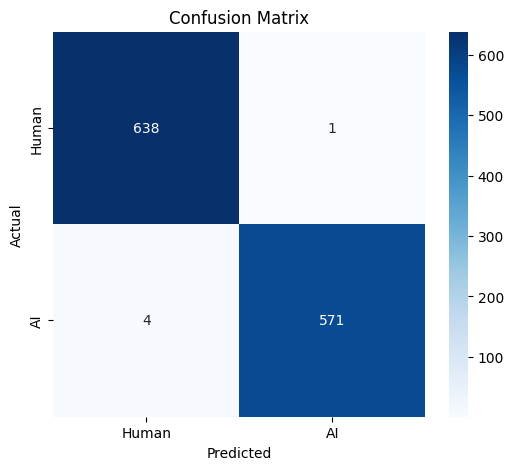

In [12]:
# =========================================
# 10. Confusion Matrix Visualization
# =========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Human','AI'],
    yticklabels=['Human','AI']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [13]:
# =========================================
# 11. Save Model and Vectorizer
# =========================================

joblib.dump(model, "logistic_model.sav")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and Vectorizer Saved Successfully")

Model and Vectorizer Saved Successfully
